## kchouse_data prediction usimg regression

 ## Objective
The project aims to understand the relationship between different features and house prices, and to compare multiple regression algorithms to find the most accurate model.

 ## Dataset
The dataset used in this project is the House Sales Prediction dataset. It contains information about house properties such as number of bedrooms, bathrooms, square footage, condition, and price.
The target variable in this dataset is price, which represents the selling price of the house.

## Steps Involved
1. Data Collection  
2. Import Libraries  
3. Data Cleaning & Preprocessing  
4. Exploratory Data Analysis (EDA)  
5. Feature Engineering & Selection  
6. Model Building  
7. Model Evaluation  
8. Testing the Model  

## Import Libraries

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split #for spliting dataset
from sklearn.preprocessing import StandardScaler # for feature scaling

from sklearn.linear_model import LinearRegression # ml model
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Loading Dataset and Preprocessing
this dataset contain:
* 20 features
* 1 target(price)
     


In [81]:
df=pd.read_csv("kchouse_data.csv")
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [83]:
df.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.401822e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.673622e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [84]:
df.shape

(21613, 21)

In [85]:
df.isnull().sum()

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

In [86]:
print(df.duplicated().sum())

0


In [87]:
df=df.drop(["id","date"],axis=1)

In [88]:
df.shape

(21613, 19)

## Insights
this dataset is cleaning:
* checking missing values
* checking datatypes
* checking duplicates
* remove unneccessary features


### Feature Scaling
Feature scaling was applied to normalize the data so that all features contribute equally to the model.

In [89]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df.drop('price', axis=1))

X = scaled_features
y = df['price']

### Boxplot
Boxplots were used to detect outliers in the dataset.


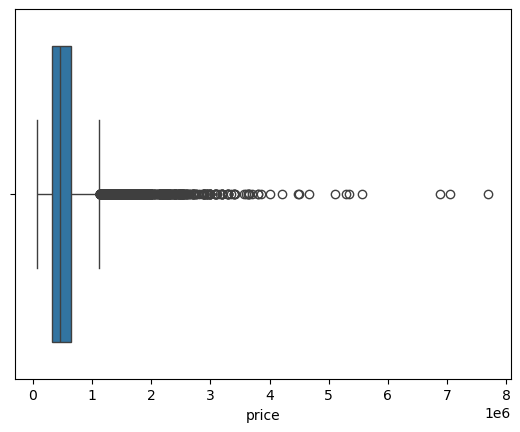

In [90]:
sns.boxplot(x=df['price'])
plt.show()

In [91]:
df = df[df['price'] < df['price'].quantile(0.99)]

### Insights
* Significant outliers were present in the price column
* Removing extreme values improved data quality


### Histogram
Histograms were used to understand the distribution of features.

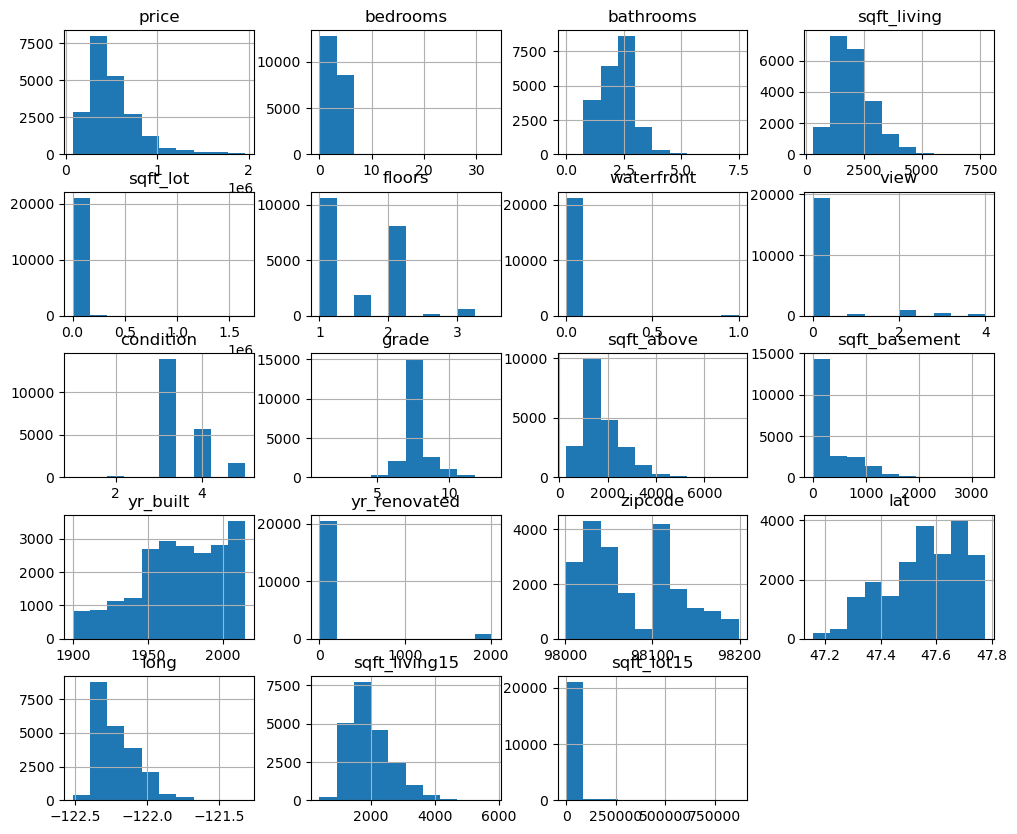

In [92]:
df.hist(figsize=(12,10))
plt.show()

### Insight
* Most houses are priced in the lower to mid-range
* The price distribution is right-skewed (few very expensive houses)
* Features like sqft_living also show skewed distribution

### Scatter Plot
Scatter plots were used to analyze relationships between features and price.

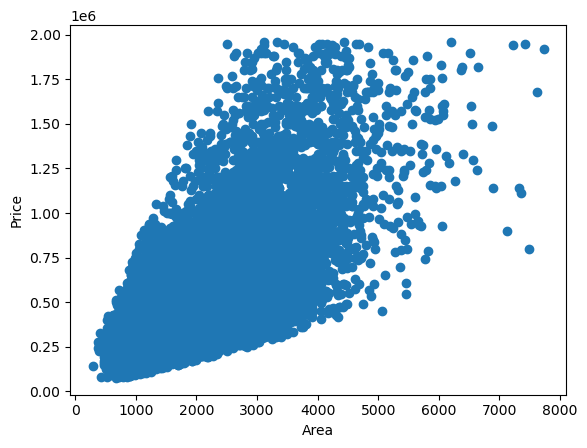

In [93]:
plt.scatter(df['sqft_living'], df['price'])
plt.xlabel("Area")
plt.ylabel("Price")
plt.show()

### Insights
* sqft_living has a strong positive relationship with price
* As living area increases, house price also increases
* Other features like bathrooms also show moderate relationships

### Correlation Heatmap
A heatmap was used to visualize correlation between variables.


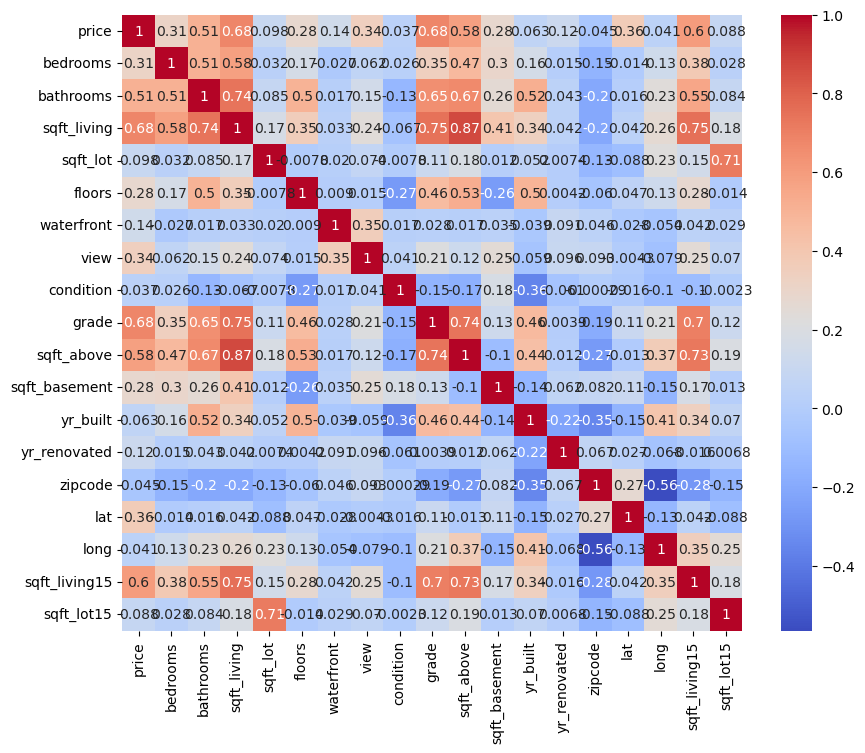

In [94]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

Insight:
* sqft_living shows the highest correlation with price
* grade and bathrooms also have strong positive correlations
* Some features have weak correlation and less impact

## Model Building

In [95]:
from sklearn.model_selection import train_test_split

X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Linear Regression
Linear Regression is a simple algorithm that assumes a linear relationship between independent variables and the target variable. It tries to fit a straight line that best predicts the output.It is easy to implement and works well when there is a linear relationship between features and price.

In [96]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

## Decision Tree Regressor
Decision Tree splits the dataset into smaller subsets based on feature values. It creates a tree-like structure where each branch represents a decision.
It can capture non-linear relationships and interactions between variables.

In [97]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

## Random Forest Regressor
Random Forest is an ensemble method that combines multiple decision trees. Each tree makes a prediction, and the final output is the average of all predictions.It improves accuracy and reduces overfitting compared to a single decision tree.

In [98]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

## Model Evaluation
Model performance is evaluated using three metrics:

* MAE (Mean Absolute Error): Measures the average error in predictions
* MSE (Mean Squared Error): Penalizes larger errors more than smaller ones
* R² Score: Indicates how well the model explains the variance in the data (closer to 1 is better)

In [99]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate(y_test, y_pred):
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("MSE:", mean_squared_error(y_test, y_pred))
    print("R2:", r2_score(y_test, y_pred))

In [100]:
print("Linear Regression")
evaluate(y_test, y_pred_lr)

print("\nDecision Tree")
evaluate(y_test, y_pred_dt)

print("\nRandom Forest")
evaluate(y_test, y_pred_rf)

Linear Regression
MAE: 107648.64493857049
MSE: 23496698369.90451
R2: 0.7050925352220444

Decision Tree
MAE: 90411.64427570094
MSE: 21308497986.389194
R2: 0.7325566758161629

Random Forest
MAE: 63259.96854333371
MSE: 10295978873.55491
R2: 0.8707749923326862


The models are compared based on their evaluation metrics. The model with the lowest error values (MAE, MSE) and highest R² score is considered the best.

### Model Comparsions Insight:
Random Forest is best because it gives more accurate predictions and handles complex relationships better than Linear Regression and Decision Tree.
Decision Tree performed moderately, while Linear Regression showed the lowest performance.


## Conclusion
In this project, regression techniques were applied . After preprocessing and analyzing the data, three models were implemented. Among them, Random Forest Regressor performed the best due to its high accuracy and ability to handle complex relationships. Therefore, it is the most suitable model for this dataset.
